Знакомство с библиотеками Pillow, Numpy, Matplotlib

PIL (Python Image Library) содержит средства для обработки изображений и разнообразных операций, таких как: изменение размера, кадрирование, поворот, преобразование цветов и т. д.

NumPy (Numeric Python) это библиотека для языка Python, которая предоставляет функции для работами с матрицами и массивами данных.

Matplotlib содержит средства для построения графиков, диаграмм, рисования точек, прямых или кривых линий.

In [39]:
# Скачиваем изображение с GitHub используя wget
!wget -q https://raw.githubusercontent.com/Nesteaxxx/Projects-labs-etc./main/sakura.png

Задание 1

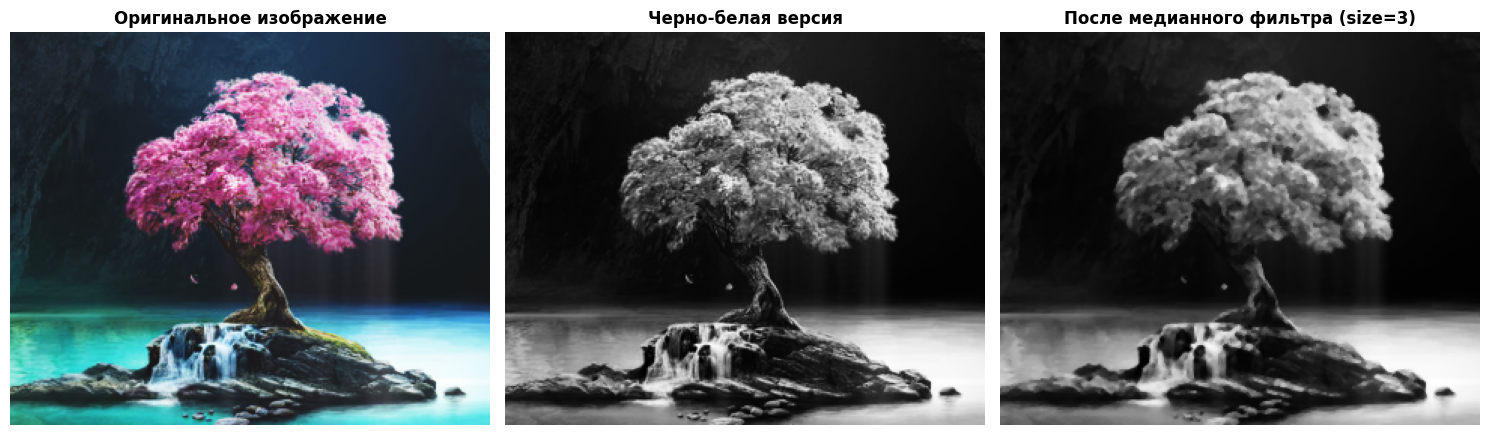

In [40]:
from PIL import Image, ImageFilter
import matplotlib.pyplot as plt

  # Загружаем изображение
origin_img = Image.open("sakura.png")

  # Конвертируем в grayscale
img_gray = origin_img.convert("L")

  # Применяем медианный фильтр
img_filtered = img_gray.filter(ImageFilter.MedianFilter(size=3))

  # Создаем фигуру для отображения
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

  # Оригинальное изображение
axes[0].imshow(origin_img)
axes[0].set_title('Оригинальное изображение', fontsize=12, fontweight='bold')
axes[0].axis('off')

  # Черно-белое изображение
axes[1].imshow(img_gray, cmap='gray')
axes[1].set_title('Черно-белая версия', fontsize=12, fontweight='bold')
axes[1].axis('off')

  # После медианного фильтра
axes[2].imshow(img_filtered, cmap='gray')
axes[2].set_title('После медианного фильтра (size=3)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Задание 2

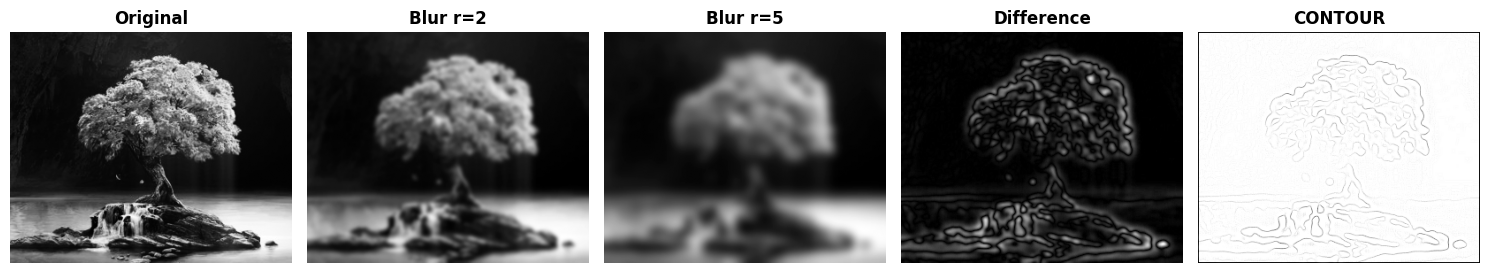

In [24]:
from PIL import Image, ImageFilter, ImageChops
import matplotlib.pyplot as plt

# Загрузка и обработка
img = Image.open("sakura.png").convert("L")
blur2 = img.filter(ImageFilter.GaussianBlur(2))
blur5 = img.filter(ImageFilter.GaussianBlur(5))
diff = ImageChops.difference(blur2, blur5)
contour = diff.filter(ImageFilter.CONTOUR)

# Отображение
fig, axes = plt.subplots(1, 5, figsize=(15, 10))

images = [img, blur2, blur5, diff, contour]
titles = ['Original', 'Blur r=2', 'Blur r=5', 'Difference', 'CONTOUR']
cmaps = ['gray'] * 5

for i, ax in enumerate(axes.flat):
    ax.imshow(images[i], cmap=cmaps[i])
    ax.set_title(titles[i], fontweight='bold')
    ax.axis('off')

plt.tight_layout()
plt.show()

Задание 3

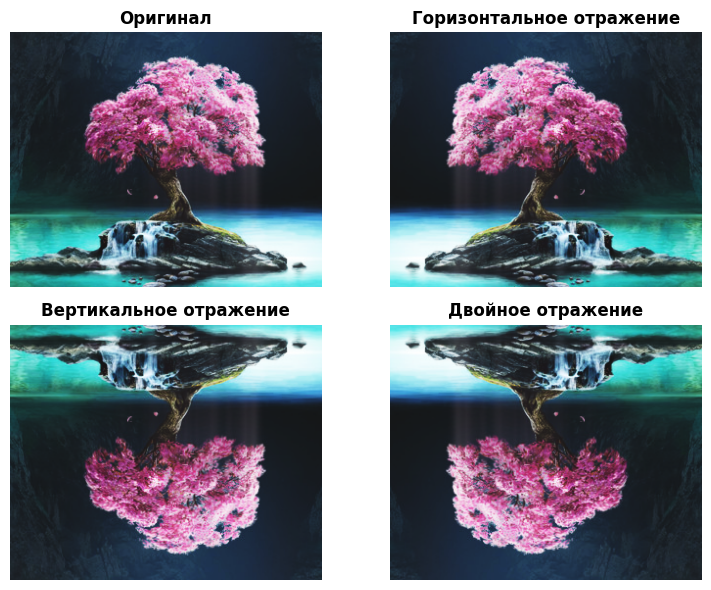

In [36]:
from PIL import Image
import matplotlib.pyplot as plt
import numpy as np

# Загрузка и обработка
im = np.array(Image.open('sakura.png'))
im_h = np.fliplr(im)  # Горизонтальное отражение
im_v = np.flipud(im)  # Вертикальное отражение

# Отображение
fig, axes = plt.subplots(2, 2, figsize=(8, 6))

# Оригинал
axes[0, 0].imshow(im)
axes[0, 0].set_title('Оригинал', fontweight='bold')
axes[0, 0].axis('off')

# Горизонтальное отражение
axes[0, 1].imshow(im_h)
axes[0, 1].set_title('Горизонтальное отражение', fontweight='bold')
axes[0, 1].axis('off')

# Вертикальное отражение
axes[1, 0].imshow(im_v)
axes[1, 0].set_title('Вертикальное отражение', fontweight='bold')
axes[1, 0].axis('off')

# Комбинированное отражение (горизонтальное + вертикальное)
im_hv = np.flipud(np.fliplr(im))
axes[1, 1].imshow(im_hv)
axes[1, 1].set_title('Двойное отражение', fontweight='bold')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

Задание 4

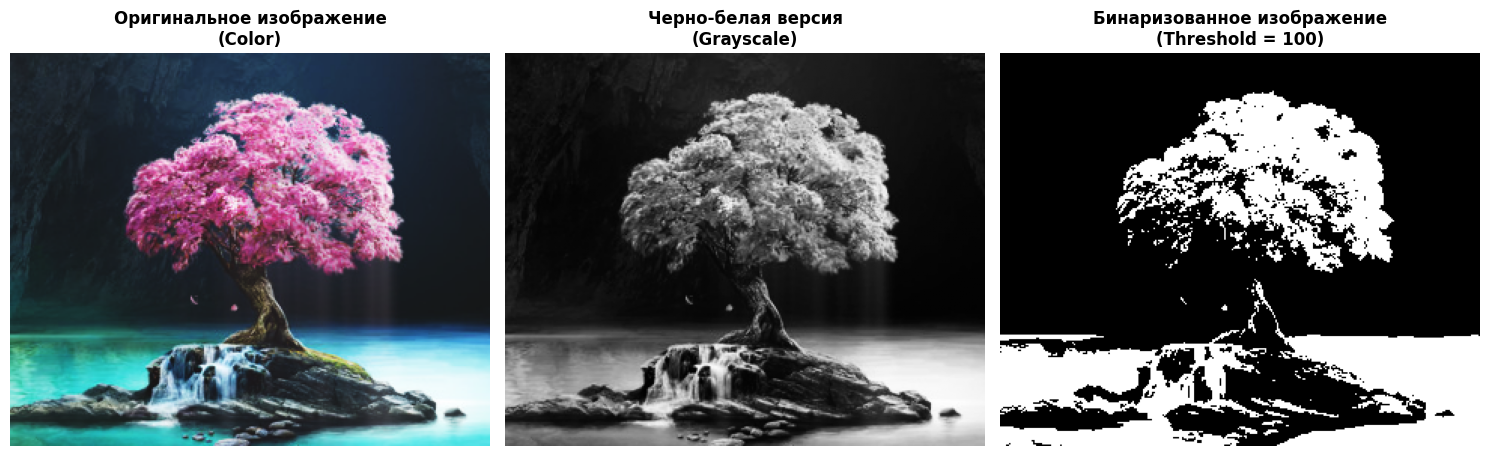

In [26]:
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def binarize_image(im_array, threshold=100):
    """
    Бинаризует изображение по пороговому значению

    Parameters:
    im_array: numpy array - входное изображение
    threshold: int - пороговое значение (0-255)

    Returns:
    numpy array - бинаризованное изображение
    """
    im_binary = (im_array > threshold) * 255
    return im_binary.astype(np.uint8)

# Загружаем и конвертируем изображение
im_original = Image.open("sakura.png")
im_gray = np.array(im_original.convert("L"))

# Бинаризуем изображение
result_binary = binarize_image(im_gray, threshold=100)

# Создаем фигуру для сравнения
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Оригинальное цветное изображение
axes[0].imshow(im_original)
axes[0].set_title('Оригинальное изображение\n(Color)', fontsize=12, fontweight='bold')
axes[0].axis('off')

# Черно-белая версия
axes[1].imshow(im_gray, cmap='gray')
axes[1].set_title('Черно-белая версия\n(Grayscale)', fontsize=12, fontweight='bold')
axes[1].axis('off')

# Бинаризованное изображение
axes[2].imshow(result_binary, cmap='gray')
axes[2].set_title('Бинаризованное изображение\n(Threshold = 100)', fontsize=12, fontweight='bold')
axes[2].axis('off')

plt.tight_layout()
plt.show()

Задание 5

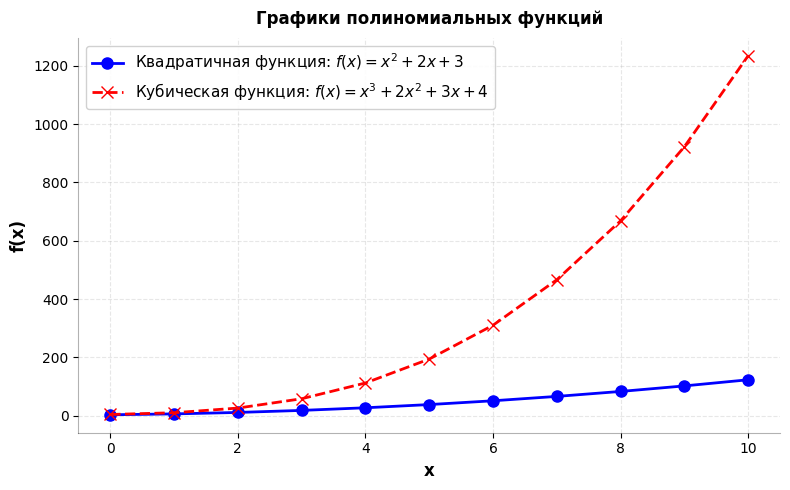

In [34]:
import matplotlib.pyplot as plt
import numpy as np

#Вычисляет значения квадратичной функции a*x^2 + b*x + c
def quadratic_function(x_values, a=1, b=2, c=3):
    return a * np.array(x_values)**2 + b * np.array(x_values) + c

#Вычисляет значения кубической функции a*x^3 + b*x^2 + c*x + d
def cubic_function(x_values, a=1, b=2, c=3, d=4):
    return a * np.array(x_values)**3 + b * np.array(x_values)**2 + c * np.array(x_values) + d

# Генерируем данные
x = np.arange(0, 11, 1)
y_quadratic = quadratic_function(x)
y_cubic = cubic_function(x)

# Создаем график
fig, ax = plt.subplots(figsize=(8, 5))

# Рисуем графики
ax.plot(x, y_quadratic, 'b-', linewidth=2, marker='o', markersize=8,
        label='Квадратичная функция: $f(x) = x^2 + 2x + 3$')
ax.plot(x, y_cubic, 'r--', linewidth=2, marker='x', markersize=8,
        label='Кубическая функция: $f(x) = x^3 + 2x^2 + 3x + 4$')

# Настраиваем оформление
ax.set_title('Графики полиномиальных функций', fontsize=12, fontweight='bold', pad=10)
ax.set_xlabel('x', fontsize=12, fontweight='bold')
ax.set_ylabel('f(x)', fontsize=12, fontweight='bold')

# Настройка сетки
ax.grid(True, alpha=0.3, linestyle='--')
ax.set_axisbelow(True)  # Сетка под графиками

# Настройка легенды
ax.legend(loc='upper left', fontsize=11, framealpha=0.9)

# Улучшаем внешний вид осей
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_alpha(0.3)
ax.spines['bottom'].set_alpha(0.3)

plt.tight_layout()
plt.show()